Import + helper

In [1]:
import json
import random
import sys
from copy import deepcopy
from pathlib import Path
from typing import Dict, Optional

import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

def find_project_root(start_path: Path, required_dir: str = "src") -> Path:
    current = start_path.resolve()
    while True:
        if (current / required_dir).exists():
            return current
        if current.parent == current:
            raise FileNotFoundError(f"Cannot find project root containing '{required_dir}'")
        current = current.parent

PROJECT_ROOT = find_project_root(Path.cwd(), required_dir="src")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.datasets.multimodal_raw_dataset import (
    MultiModalRawDataset,
    multimodal_raw_collate_fn,
)
from src.models.multimodal.multimodal_text_guided_pvd_infonce_supcon import (
    MultimodalTextGuidedPVDInfoNCESupCon,
)
from src.models.losses.wrapper_loss import InfoNCESupConLoss

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Imports OK")

def set_random_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

PROJECT_ROOT: /media/data3/users/luongdth/MulCo-PlantNet
Imports OK


Config

In [2]:
def get_training_config():
    return {
        "data": {
            "train_image_root": "data/AIDG/dataset_PlantDoc/images/train",
            "train_caption_root": "data/AIDG/captions_LLaVA/train",

            # KHỚP train/validate theo raw multimodal
            "val_image_root": "data/AIDG/dataset_PlantDoc/images/validation",
            "val_caption_root": "data/AIDG/captions_LLaVA/validation",

            "img_size": 224,
            "use_depth_suppressed": False,
            "strict_caption_match": True,
        },
        "model": {
            "num_classes": 28,
            "clip_model_name": "ViT-L-14",
            "clip_pretrained": "openai",
            "text_input_dim": 768,
            "image_input_dim": 1024,
            "proj_dim": 512,
            "proj_hidden_dim": 768,
            "pvd_hidden_dim": 768,
            "cls_hidden_dim": 1024,
            "dropout": 0.3,
            "normalize_projection": True,
            "freeze_convnext_backbone": True,
        },
        "loss": {
            "ce_weight": 1.0,
            "itc_weight": 0.2,
            "supcon_weight": 0.2,
            "itc_temperature": 0.07,
            "supcon_temperature": 0.07,
        },
        "optimizer": {
            "lr": 1e-4,
            "weight_decay": 1e-4,
        },
        "scheduler": {
            "mode": "max",
            "factor": 0.5,
            "patience": 3,
            "min_lr": 1e-6,
        },
        "training": {
            "seed": 42,
            "device": "auto",
            "batch_size": 2,  # Giảm batch_size xuống để vừa với VRAM hiện tại
            "num_workers": 0,
            "epochs": 30,   # train tiếp đến epoch 30 chẳng hạn
            "save_dir": "archive/text_guided_infonce_supcon_multihead_attention_pvd",
            "monitor_metric": "accuracy",
            "monitor_mode": "max",
            "early_stopping_patience": 7,
            "early_stopping_min_delta": 0.0,
            "save_best": True,
            "save_last": True,
        },
    }

config = get_training_config()
config

{'data': {'train_image_root': 'data/AIDG/dataset_PlantDoc/images/train',
  'train_caption_root': 'data/AIDG/captions_LLaVA/train',
  'val_image_root': 'data/AIDG/dataset_PlantDoc/images/validation',
  'val_caption_root': 'data/AIDG/captions_LLaVA/validation',
  'img_size': 224,
  'use_depth_suppressed': False,
  'strict_caption_match': True},
 'model': {'num_classes': 28,
  'clip_model_name': 'ViT-L-14',
  'clip_pretrained': 'openai',
  'text_input_dim': 768,
  'image_input_dim': 1024,
  'proj_dim': 512,
  'proj_hidden_dim': 768,
  'pvd_hidden_dim': 768,
  'cls_hidden_dim': 1024,
  'dropout': 0.3,
  'normalize_projection': True,
  'freeze_convnext_backbone': True},
 'loss': {'ce_weight': 1.0,
  'itc_weight': 0.2,
  'supcon_weight': 0.2,
  'itc_temperature': 0.07,
  'supcon_temperature': 0.07},
 'optimizer': {'lr': 0.0001, 'weight_decay': 0.0001},
 'scheduler': {'mode': 'max', 'factor': 0.5, 'patience': 3, 'min_lr': 1e-06},
 'training': {'seed': 42,
  'device': 'auto',
  'batch_size': 2

Helper function

In [3]:
class EarlyStopping:
    def __init__(self, patience=10, mode="max", min_delta=0.0):
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, current_score):
        if self.best_score is None:
            self.best_score = current_score
            return True

        if self.mode == "max":
            improved = current_score > self.best_score + self.min_delta
        elif self.mode == "min":
            improved = current_score < self.best_score - self.min_delta
        else:
            raise ValueError("mode must be 'max' or 'min'")

        if improved:
            self.best_score = current_score
            self.counter = 0
            return True

        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
        return False


def resolve_device(device_name: str):
    if device_name == "auto":
        return "cuda" if torch.cuda.is_available() else "cpu"
    return device_name


def build_transforms(img_size: int):
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.05
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    return train_transform, val_transform


def save_checkpoint(path, model, optimizer, scheduler, epoch, best_metric, history, config):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "best_metric": best_metric,
        "history": history,
        "config": config,
    }
    torch.save(checkpoint, path)


def load_checkpoint(path, model, optimizer=None, scheduler=None, map_location="cpu"):
    checkpoint = torch.load(path, map_location=map_location)
    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and checkpoint.get("optimizer_state_dict") is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    return checkpoint

Create dataset + data loader

In [4]:
def create_datasets_and_loaders(config: Dict):
    train_transform, val_transform = build_transforms(config["data"]["img_size"])

    train_dataset = MultiModalRawDataset(
        image_root=PROJECT_ROOT / config["data"]["train_image_root"],
        caption_root=PROJECT_ROOT / config["data"]["train_caption_root"],
        transform=train_transform,
        use_depth_suppressed=config["data"]["use_depth_suppressed"],
        strict_caption_match=config["data"]["strict_caption_match"],
    )

    val_dataset = None
    val_loader = None

    val_image_root = config["data"].get("val_image_root")
    val_caption_root = config["data"].get("val_caption_root")

    if val_image_root is not None and val_caption_root is not None:
        full_val_image_root = PROJECT_ROOT / val_image_root
        full_val_caption_root = PROJECT_ROOT / val_caption_root

        if full_val_image_root.exists() and full_val_caption_root.exists():
            val_dataset = MultiModalRawDataset(
                image_root=full_val_image_root,
                caption_root=full_val_caption_root,
                transform=val_transform,
                use_depth_suppressed=config["data"]["use_depth_suppressed"],
                strict_caption_match=config["data"]["strict_caption_match"],
            )
        else:
            print("[WARN] Validation paths do not exist. Validation will be skipped.")
            print("[WARN] val_image_root:", full_val_image_root)
            print("[WARN] val_caption_root:", full_val_caption_root)
    else:
        print("[INFO] Validation roots are None. Validation will be skipped.")

    num_workers = config["training"]["num_workers"]
    pin_memory = torch.cuda.is_available()

    train_loader = DataLoader(
        train_dataset,
        batch_size=config["training"]["batch_size"],
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        collate_fn=multimodal_raw_collate_fn,
    )

    if val_dataset is not None:
        val_loader = DataLoader(
            val_dataset,
            batch_size=config["training"]["batch_size"],
            shuffle=False,
            num_workers=num_workers,
            pin_memory=pin_memory,
            collate_fn=multimodal_raw_collate_fn,
        )

    return train_dataset, val_dataset, train_loader, val_loader

Create model, loss, optimizer, scheduler

In [5]:
def create_training_components(config: Dict):
    device = resolve_device(config["training"]["device"])

    model = MultimodalTextGuidedPVDInfoNCESupCon(
        num_classes=config["model"]["num_classes"],
        clip_model_name=config["model"]["clip_model_name"],
        clip_pretrained=config["model"]["clip_pretrained"],
        text_input_dim=config["model"]["text_input_dim"],
        image_input_dim=config["model"]["image_input_dim"],
        proj_dim=config["model"]["proj_dim"],
        proj_hidden_dim=config["model"]["proj_hidden_dim"],
        pvd_hidden_dim=config["model"]["pvd_hidden_dim"],
        cls_hidden_dim=config["model"]["cls_hidden_dim"],
        dropout=config["model"]["dropout"],
        normalize_projection=config["model"]["normalize_projection"],
        device=device,
    ).to(device)

    # =========================================================
    # Freeze ConvNeXt backbone, keep Text-Guided CBAM trainable
    # =========================================================
    if config["model"].get("freeze_convnext_backbone", False):
        # Freeze backbone ConvNeXt
        for param in model.image_encoder.model.parameters():
            param.requires_grad = False

        # Keep Text-Guided CBAM trainable
        for module in [
            model.image_encoder.tgcbam1,
            model.image_encoder.tgcbam2,
            model.image_encoder.tgcbam3,
            model.image_encoder.tgcbam4,
        ]:
            for param in module.parameters():
                param.requires_grad = True

        # Keep final norm trainable
        for param in model.image_encoder.norm4.parameters():
            param.requires_grad = True

        print("[INFO] ConvNeXt backbone frozen.")
        print("[INFO] Text-Guided CBAM modules remain trainable.")

    criterion = InfoNCESupConLoss(
        ce_weight=config["loss"]["ce_weight"],
        itc_weight=config["loss"]["itc_weight"],
        supcon_weight=config["loss"]["supcon_weight"],
        itc_temperature=config["loss"]["itc_temperature"],
        supcon_temperature=config["loss"]["supcon_temperature"],
    )

    trainable_params = [p for p in model.parameters() if p.requires_grad]

    optimizer = torch.optim.AdamW(
        trainable_params,
        lr=config["optimizer"]["lr"],
        weight_decay=config["optimizer"]["weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode=config["scheduler"]["mode"],
        factor=config["scheduler"]["factor"],
        patience=config["scheduler"]["patience"],
        min_lr=config["scheduler"]["min_lr"],
    )

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"[INFO] Total params: {total_params:,}")
    print(f"[INFO] Trainable params: {trainable_params_count:,}")
    print(f"[INFO] Frozen params: {total_params - trainable_params_count:,}")
    print(f"[INFO] Trainable ratio: {trainable_params_count / total_params:.4f}")

    return model, criterion, optimizer, scheduler, device

In [6]:
model, criterion, optimizer, scheduler, device = create_training_components(config)

print("\n===== TRAINABLE PARAMETERS =====")
for name, param in model.named_parameters():
    if param.requires_grad:
        print("[TRAIN]", name)

print("\n===== CHECK BACKBONE FROZEN =====")
backbone_trainable = any(
    p.requires_grad for p in model.image_encoder.model.parameters()
)
print("Backbone trainable:", backbone_trainable)

/media/data3/users/luongdth/anaconda3/envs/gr1/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[INFO] ConvNeXt backbone frozen.
[INFO] Text-Guided CBAM modules remain trainable.
[INFO] Total params: 525,669,381
[INFO] Trainable params: 9,461,404
[INFO] Frozen params: 516,207,977
[INFO] Trainable ratio: 0.0180

===== TRAINABLE PARAMETERS =====
[TRAIN] image_encoder.tgcbam1.channel_attention.shared_mlp.0.weight
[TRAIN] image_encoder.tgcbam1.channel_attention.shared_mlp.2.weight
[TRAIN] image_encoder.tgcbam1.spatial_attention.query_proj.weight
[TRAIN] image_encoder.tgcbam1.spatial_attention.key_proj.weight
[TRAIN] image_encoder.tgcbam1.spatial_attention.value_proj.weight
[TRAIN] image_encoder.tgcbam1.spatial_attention.out_proj.weight
[TRAIN] image_encoder.tgcbam2.channel_attention.shared_mlp.0.weight
[TRAIN] image_encoder.tgcbam2.channel_attention.shared_mlp.2.weight
[TRAIN] image_encoder.tgcbam2.spatial_attention.query_proj.weight
[TRAIN] image_encoder.tgcbam2.spatial_attention.key_proj.weight
[TRAIN] image_encoder.tgcbam2.spatial_attention.value_proj.weight
[TRAIN] image_encoder.

Validate function

In [7]:
@torch.no_grad()
def validate_text_guided_contrastive(model, dataloader, criterion, device="cpu"):
    model.eval()

    total_samples = 0
    total_correct = 0

    running_loss = 0.0
    running_ce = 0.0
    running_itc = 0.0
    running_supcon = 0.0

    progress_bar = tqdm(dataloader, desc="Validating", leave=False)

    for batch in progress_bar:
        images = batch["image"].to(device)
        texts = batch["text"]
        labels = batch["label"].to(device)

        outputs = model(images, texts)
        loss_dict = criterion(outputs, labels)

        logits = outputs["logits"]
        preds = torch.argmax(logits, dim=1)

        batch_size = labels.size(0)
        total_samples += batch_size
        total_correct += (preds == labels).sum().item()

        running_loss += loss_dict["loss"].item() * batch_size
        running_ce += loss_dict["loss_ce"].item() * batch_size
        running_itc += loss_dict["loss_itc"].item() * batch_size
        running_supcon += loss_dict["loss_supcon"].item() * batch_size

        progress_bar.set_postfix({
            "loss": f"{running_loss / max(total_samples, 1):.4f}",
            "acc": f"{total_correct / max(total_samples, 1):.4f}",
        })

    if total_samples == 0:
        return {
            "loss": 0.0,
            "loss_ce": 0.0,
            "loss_itc": 0.0,
            "loss_supcon": 0.0,
            "accuracy": 0.0,
        }

    return {
        "loss": running_loss / total_samples,
        "loss_ce": running_ce / total_samples,
        "loss_itc": running_itc / total_samples,
        "loss_supcon": running_supcon / total_samples,
        "accuracy": total_correct / total_samples,
    }

Train one epoch

In [8]:
def train_one_epoch_text_guided_contrastive(
    model,
    dataloader,
    criterion,
    optimizer,
    device="cpu"
):
    model.train()

    total_samples = 0
    total_correct = 0

    running_loss = 0.0
    running_ce = 0.0
    running_itc = 0.0
    running_supcon = 0.0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for batch in progress_bar:
        images = batch["image"].to(device)
        texts = batch["text"]
        labels = batch["label"].to(device)

        outputs = model(images, texts)
        loss_dict = criterion(outputs, labels)
        loss = loss_dict["loss"]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        logits = outputs["logits"]
        preds = torch.argmax(logits, dim=1)

        batch_size = labels.size(0)
        total_samples += batch_size
        total_correct += (preds == labels).sum().item()

        running_loss += loss.item() * batch_size
        running_ce += loss_dict["loss_ce"].item() * batch_size
        running_itc += loss_dict["loss_itc"].item() * batch_size
        running_supcon += loss_dict["loss_supcon"].item() * batch_size

        progress_bar.set_postfix({
            "loss": f"{running_loss / max(total_samples, 1):.4f}",
            "acc": f"{total_correct / max(total_samples, 1):.4f}",
        })

    if total_samples == 0:
        return {
            "loss": 0.0,
            "loss_ce": 0.0,
            "loss_itc": 0.0,
            "loss_supcon": 0.0,
            "accuracy": 0.0,
        }

    return {
        "loss": running_loss / total_samples,
        "loss_ce": running_ce / total_samples,
        "loss_itc": running_itc / total_samples,
        "loss_supcon": running_supcon / total_samples,
        "accuracy": total_correct / total_samples,
    }

Full training loop

In [9]:
def train_text_guided_contrastive(
    config: Dict,
    resume_from: Optional[str] = None
):
    set_random_seed(config["training"]["seed"])
    device = resolve_device(config["training"]["device"])

    save_dir = PROJECT_ROOT / config["training"]["save_dir"]
    save_dir.mkdir(parents=True, exist_ok=True)

    train_dataset, val_dataset, train_loader, val_loader = create_datasets_and_loaders(config)
    model, criterion, optimizer, scheduler, device = create_training_components(config)

    start_epoch = 1
    history = []
    best_metric = None

    if resume_from is not None:
        checkpoint = load_checkpoint(
            resume_from,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            map_location=device,
        )
        start_epoch = checkpoint["epoch"] + 1
        history = checkpoint.get("history", [])
        best_metric = checkpoint.get("best_metric", None)
        print(f"[INFO] Resumed from checkpoint: {resume_from}")
        print(f"[INFO] Start epoch: {start_epoch}")

    early_stopping = EarlyStopping(
        patience=config["training"]["early_stopping_patience"],
        mode=config["training"]["monitor_mode"],
        min_delta=config["training"]["early_stopping_min_delta"],
    )

    if best_metric is not None:
        early_stopping.best_score = best_metric

    monitor_metric = config["training"]["monitor_metric"]
    monitor_mode = config["training"]["monitor_mode"]
    use_validation = val_loader is not None

    print(f"[INFO] Validation enabled: {use_validation}")

    for epoch in range(start_epoch, config["training"]["epochs"] + 1):
        print("=" * 80)
        print(f"Epoch [{epoch}/{config['training']['epochs']}]")

        train_metrics = train_one_epoch_text_guided_contrastive(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )

        if use_validation:
            val_metrics = validate_text_guided_contrastive(
                model=model,
                dataloader=val_loader,
                criterion=criterion,
                device=device,
            )
            current_metric = val_metrics[monitor_metric]
            metric_source = "validation"
        else:
            val_metrics = None
            current_metric = train_metrics[monitor_metric]
            metric_source = "train"

        scheduler.step(current_metric)
        is_best = early_stopping.step(current_metric)

        if best_metric is None:
            best_metric = current_metric
        else:
            if monitor_mode == "max":
                best_metric = max(best_metric, current_metric)
            else:
                best_metric = min(best_metric, current_metric)

        epoch_record = {
            "epoch": epoch,
            "train": train_metrics,
            "validation": val_metrics,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "metric_source": metric_source,
        }
        history.append(epoch_record)

        print(
            f"Train      | "
            f"loss={train_metrics['loss']:.4f} "
            f"ce={train_metrics['loss_ce']:.4f} "
            f"itc={train_metrics['loss_itc']:.4f} "
            f"supcon={train_metrics['loss_supcon']:.4f} "
            f"acc={train_metrics['accuracy']:.4f}"
        )

        if val_metrics is not None:
            print(
                f"Validation | "
                f"loss={val_metrics['loss']:.4f} "
                f"ce={val_metrics['loss_ce']:.4f} "
                f"itc={val_metrics['loss_itc']:.4f} "
                f"supcon={val_metrics['loss_supcon']:.4f} "
                f"acc={val_metrics['accuracy']:.4f}"
            )
        else:
            print("[INFO] Validation skipped.")

        print(f"[INFO] Monitor source: {metric_source}")
        print(f"Learning rate: {optimizer.param_groups[0]['lr']:.8f}")

        if config["training"].get("save_last", True):
            save_checkpoint(
                save_dir / "last_model.pt",
                model,
                optimizer,
                scheduler,
                epoch,
                best_metric,
                history,
                config,
            )

        if is_best and config["training"].get("save_best", True):
            save_checkpoint(
                save_dir / "best_model.pt",
                model,
                optimizer,
                scheduler,
                epoch,
                best_metric,
                history,
                config,
            )
            print(f"[INFO] Saved best model at epoch {epoch}")

        if early_stopping.should_stop:
            print(f"[INFO] Early stopping triggered at epoch {epoch}")
            break

    history_path = save_dir / "history.json"
    with open(history_path, "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2, ensure_ascii=False)

    print("[INFO] Training finished.")
    print("[INFO] Best metric:", best_metric)
    print("[INFO] History saved to:", history_path)

    return {
        "model": model,
        "history": history,
        "best_metric": best_metric,
        "save_dir": save_dir,
    }

In [10]:
from pathlib import Path

print("train image exists:", (PROJECT_ROOT / "data/AIDG/dataset_PlantDoc/images/train").exists())
print("val image exists:", (PROJECT_ROOT / "data/AIDG/dataset_PlantDoc/images/val").exists())
print("train caption exists:", (PROJECT_ROOT / "data/AIDG/captions_LLaVA/train").exists())
print("val caption exists:", (PROJECT_ROOT / "data/AIDG/captions_LLaVA/val").exists())

train image exists: True
val image exists: False
train caption exists: True
val caption exists: False


In [11]:
result = train_text_guided_contrastive(config=config)
history = result["history"]

[MultiModalRawDataset] Total selected images: 2336
[MultiModalRawDataset] Valid samples: 2336
[MultiModalRawDataset] Skipped missing caption: 0
[MultiModalRawDataset] Skipped invalid caption: 0
[MultiModalRawDataset] Num classes: 28
[MultiModalRawDataset] class_to_idx: {'Apple_Scab_Leaf': 0, 'Apple_leaf': 1, 'Apple_rust_leaf': 2, 'Bell_pepper_leaf': 3, 'Bell_pepper_leaf_spot': 4, 'Blueberry_leaf': 5, 'Cherry_leaf': 6, 'Corn_Gray_leaf_spot': 7, 'Corn_leaf_blight': 8, 'Corn_rust_leaf': 9, 'Peach_leaf': 10, 'Potato_leaf_early_blight': 11, 'Potato_leaf_late_blight': 12, 'Raspberry_leaf': 13, 'Soyabean_leaf': 14, 'Squash_Powdery_mildew_leaf': 15, 'Strawberry_leaf': 16, 'Tomato_Early_blight_leaf': 17, 'Tomato_Septoria_leaf_spot': 18, 'Tomato_leaf': 19, 'Tomato_leaf_bacterial_spot': 20, 'Tomato_leaf_late_blight': 21, 'Tomato_leaf_mosaic_virus': 22, 'Tomato_leaf_yellow_virus': 23, 'Tomato_mold_leaf': 24, 'Tomato_two_spotted_spider_mites_leaf': 25, 'grape_leaf': 26, 'grape_leaf_black_rot': 27}


Training:   0%|          | 0/1168 [00:00<?, ?it/s]

Train      | loss=2.3228 ce=2.2028 itc=0.6000 supcon=0.0000 acc=0.3527
[INFO] Validation skipped.
[INFO] Monitor source: train
Learning rate: 0.00010000
[INFO] Saved best model at epoch 1
Epoch [2/30]


Training:   0%|          | 0/1168 [00:00<?, ?it/s]

Train      | loss=1.5726 ce=1.4830 itc=0.4476 supcon=0.0001 acc=0.5304
[INFO] Validation skipped.
[INFO] Monitor source: train
Learning rate: 0.00010000
[INFO] Saved best model at epoch 2
Epoch [3/30]


...

Train      | loss=0.8395 ce=0.7823 itc=0.2862 supcon=0.0000 acc=0.7393
[INFO] Validation skipped.
[INFO] Monitor source: train
Learning rate: 0.00005000
Epoch [29/30]


Training:   0%|          | 0/1168 [00:00<?, ?it/s]

Train      | loss=0.6984 ce=0.6456 itc=0.2635 supcon=0.0000 acc=0.7834
[INFO] Validation skipped.
[INFO] Monitor source: train
Learning rate: 0.00005000
[INFO] Saved best model at epoch 29
Epoch [30/30]


Training:   0%|          | 0/1168 [00:00<?, ?it/s]

Train      | loss=0.6946 ce=0.6400 itc=0.2729 supcon=0.0000 acc=0.7855
[INFO] Validation skipped.
[INFO] Monitor source: train
Learning rate: 0.00005000
[INFO] Saved best model at epoch 30
[INFO] Training finished.
[INFO] Best metric: 0.7855308219178082
[INFO] History saved to: /media/data3/users/luongdth/MulCo-PlantNet/archive/text_guided_infonce_supcon_multihead_attention_pvd/history.json


Plot history

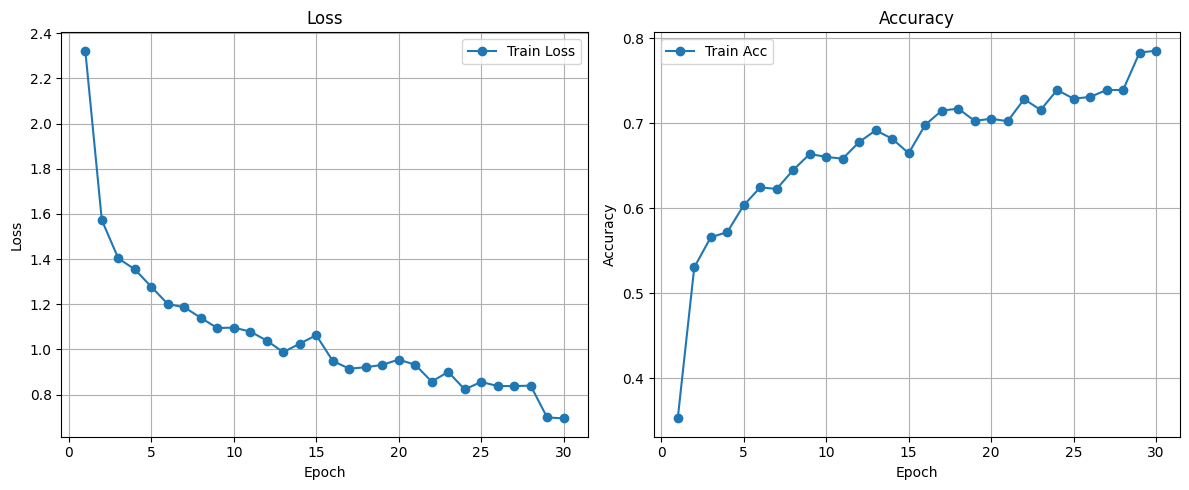

In [12]:
import matplotlib.pyplot as plt

epochs = [x["epoch"] for x in history]
train_loss = [x["train"]["loss"] for x in history]
train_acc = [x["train"]["accuracy"] for x in history]

has_validation = any(x.get("validation") is not None for x in history)

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, marker="o", label="Train Loss")

if has_validation:
    val_loss = [
        x["validation"]["loss"] if x.get("validation") is not None else None
        for x in history
    ]
    plt.plot(epochs, val_loss, marker="o", label="Val Loss")

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, marker="o", label="Train Acc")

if has_validation:
    val_acc = [
        x["validation"]["accuracy"] if x.get("validation") is not None else None
        for x in history
    ]
    plt.plot(epochs, val_acc, marker="o", label="Val Acc")

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Resume training

In [13]:
# RESUME_PATH = PROJECT_ROOT / "archive" / "text_guided_infonce_supcon_multihead_attention_pvd" / "last_model.pt"
# print("RESUME_PATH:", RESUME_PATH)
# print("Exists:", RESUME_PATH.exists())

In [14]:
# # Cập nhật số epoch tổng mới (ví dụ: train tiếp đến epoch 50)
# config["training"]["epochs"] = 40

# train_text_guided_contrastive(
#     config=config,
#     resume_from=str(RESUME_PATH)
# )